#### Libraries + Configuration

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [3]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [4]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


### Differences in Disclosure Timing Patterns by Consolidated vs. Separate Financial Statements

Analysis sample size: 8,551

=== Disclosure Timing Patterns by Financial Statement Type ===
     fs_type  total  after_total  after_pct  bad_total  bad_after  bad_after_pct  bad_ratio_pct
    Separate   1392          598       43.0        661        319           48.3           47.5
Consolidated   7159         3026       42.3       3363       1568           46.6           47.0

=== Contingency Table: Financial Statement Type × After-hours Disclosure ===
after_dummy      0     1
fs_type                 
Separate       794   598
Consolidated  4133  3026

=== Chi-square Test 1: Financial Statement Type × After-hours Disclosure ===
chi2 = 0.201
p-value = 0.6542

=== Contingency Table: Financial Statement Type × After-hours Disclosure (Bad News Only) ===
after_dummy      0     1
fs_type                 
Separate       342   319
Consolidated  1795  1568

=== Chi-square Test 2: Financial Statement Type × After-hours Disclosure (Bad News Only) ===
chi2 = 0.529
p-value = 0.4669

=== Difference-

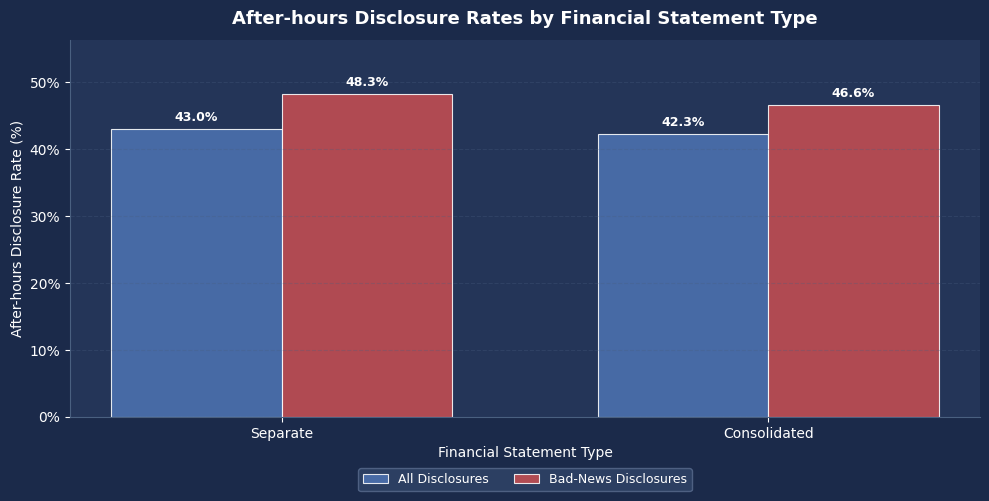

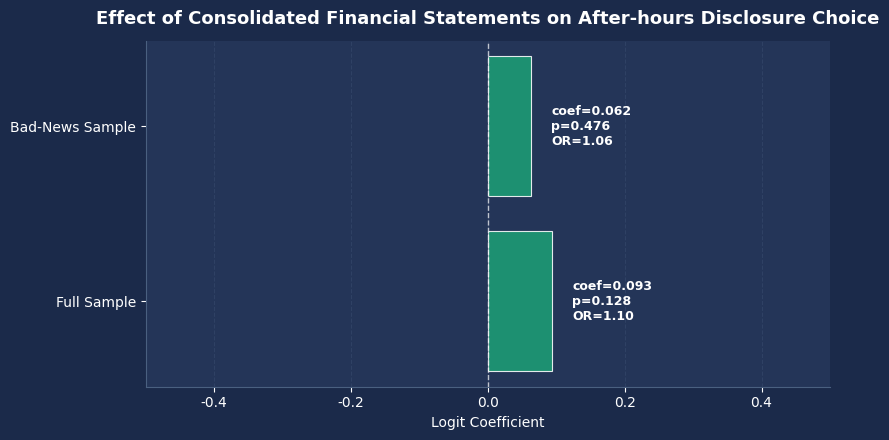


Saved output files:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\08_fs_type_after_ratio.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\08_fs_type_logit_coef.png


In [5]:
# ============================================================
# 8. Differences in Disclosure Timing Patterns by Financial Statement Type
# - Consolidated vs. separate financial statements
# - Test differences in after-hours disclosure rates and
#   after-hours bad-news disclosure rates by financial statement type
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import statsmodels.formula.api as smf

BG_COLOR = "#1B2A4A"


# ------------------------------------------------------------
# 1. Prepare analysis data
# ------------------------------------------------------------

fs_df = df_hb.copy()

# Standardize news labels
news_map = {
    "호재": "Good News",
    "악재": "Bad News",
    "Good News": "Good News",
    "Bad News": "Bad News",
    "good": "Good News",
    "bad": "Bad News"
}

fs_df["news_std"] = (
    fs_df["news"]
    .astype(str)
    .str.strip()
    .replace(news_map)
)


# Standardize disclosure timing labels
timing_map = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours",
    "Pre-market": "Pre-market",
    "Pre-Market": "Pre-market",
    "Intraday": "Intraday",
    "After-hours": "After-hours",
    "After-Hours": "After-hours"
}

fs_df["timing_std"] = (
    fs_df["timing"]
    .astype(str)
    .str.strip()
    .replace(timing_map)
)


# Keep only valid news and timing observations
fs_df = fs_df[
    fs_df["news_std"].isin(["Good News", "Bad News"]) &
    fs_df["timing_std"].isin(
        ["Pre-market", "Intraday", "After-hours"]
    )
].copy()

print(f"Analysis sample size: {len(fs_df):,}")

if len(fs_df) == 0:
    raise ValueError(
        "No valid observations remain after filtering. "
        "Check the unique values in the 'news' and 'timing' columns."
    )


# Classify consolidated vs. separate financial statements
if "is_consolidated" not in fs_df.columns:

    # Detect both Korean and English report-name conventions
    fs_df["is_consolidated"] = (
        fs_df["report_nm"]
        .astype(str)
        .str.contains(
            "연결|consolidated",
            case=False,
            na=False,
            regex=True
        )
        .astype(int)
    )

else:
    fs_df["is_consolidated"] = pd.to_numeric(
        fs_df["is_consolidated"],
        errors="coerce"
    ).fillna(0).astype(int)


fs_df["fs_type"] = np.where(
    fs_df["is_consolidated"] == 1,
    "Consolidated",
    "Separate"
)

fs_df["fs_type"] = pd.Categorical(
    fs_df["fs_type"],
    categories=["Separate", "Consolidated"],
    ordered=True
)


# Create binary variables
fs_df["after_dummy"] = (
    fs_df["timing_std"] == "After-hours"
).astype(int)

fs_df["bad_dummy"] = (
    fs_df["news_std"] == "Bad News"
).astype(int)

fs_df["bad_after"] = (
    (fs_df["bad_dummy"] == 1) &
    (fs_df["after_dummy"] == 1)
).astype(int)


# ------------------------------------------------------------
# 2. Descriptive statistics
# ------------------------------------------------------------

fs_summary = (
    fs_df
    .groupby("fs_type", observed=False)
    .agg(
        total=("news_std", "size"),
        after_total=("after_dummy", "sum"),
        bad_total=("bad_dummy", "sum"),
        bad_after=("bad_after", "sum"),
        bad_ratio=("bad_dummy", "mean")
    )
    .reset_index()
)


fs_summary["after_pct"] = (
    fs_summary["after_total"]
    / fs_summary["total"]
    * 100
)

fs_summary["bad_after_pct"] = np.where(
    fs_summary["bad_total"] > 0,
    fs_summary["bad_after"]
    / fs_summary["bad_total"]
    * 100,
    np.nan
)

fs_summary["bad_ratio_pct"] = (
    fs_summary["bad_ratio"] * 100
)


print(
    "\n=== Disclosure Timing Patterns "
    "by Financial Statement Type ==="
)

print(
    fs_summary[
        [
            "fs_type",
            "total",
            "after_total",
            "after_pct",
            "bad_total",
            "bad_after",
            "bad_after_pct",
            "bad_ratio_pct"
        ]
    ]
    .round({
        "after_pct": 1,
        "bad_after_pct": 1,
        "bad_ratio_pct": 1
    })
    .to_string(index=False)
)


# ------------------------------------------------------------
# 3. Chi-square test 1:
#    Financial statement type × after-hours disclosure
# ------------------------------------------------------------

cont_after = pd.crosstab(
    fs_df["fs_type"],
    fs_df["after_dummy"]
)

print(
    "\n=== Contingency Table: "
    "Financial Statement Type × After-hours Disclosure ==="
)

print(cont_after)


# Verify that the contingency table is valid
if cont_after.shape[0] < 2 or cont_after.shape[1] < 2:

    print(
        "\nChi-square Test 1 could not be performed "
        "because the contingency table does not contain "
        "at least two categories in both dimensions."
    )

    chi2_after = np.nan
    p_after = np.nan
    dof_after = np.nan
    expected_after = None

else:

    chi2_after, p_after, dof_after, expected_after = (
        stats.chi2_contingency(cont_after)
    )

    print(
        "\n=== Chi-square Test 1: "
        "Financial Statement Type × After-hours Disclosure ==="
    )

    print(f"chi2 = {chi2_after:.3f}")
    print(f"p-value = {p_after:.4f}")


# ------------------------------------------------------------
# 4. Chi-square test 2:
#    Financial statement type × after-hours disclosure
#    within bad-news observations
# ------------------------------------------------------------

bad_fs = fs_df[
    fs_df["bad_dummy"] == 1
].copy()

cont_bad_after = pd.crosstab(
    bad_fs["fs_type"],
    bad_fs["after_dummy"]
)

print(
    "\n=== Contingency Table: "
    "Financial Statement Type × After-hours Disclosure "
    "(Bad News Only) ==="
)

print(cont_bad_after)


if (
    cont_bad_after.shape[0] < 2
    or cont_bad_after.shape[1] < 2
):

    print(
        "\nChi-square Test 2 could not be performed "
        "because the contingency table does not contain "
        "at least two categories in both dimensions."
    )

    chi2_bad = np.nan
    p_bad = np.nan
    dof_bad = np.nan
    expected_bad = None

else:

    chi2_bad, p_bad, dof_bad, expected_bad = (
        stats.chi2_contingency(cont_bad_after)
    )

    print(
        "\n=== Chi-square Test 2: "
        "Financial Statement Type × "
        "After-hours Disclosure (Bad News Only) ==="
    )

    print(f"chi2 = {chi2_bad:.3f}")
    print(f"p-value = {p_bad:.4f}")


# ------------------------------------------------------------
# 5. Difference-in-means tests
# ------------------------------------------------------------

sep_after = fs_df.loc[
    fs_df["fs_type"] == "Separate",
    "after_dummy"
]

con_after = fs_df.loc[
    fs_df["fs_type"] == "Consolidated",
    "after_dummy"
]


if len(sep_after) > 1 and len(con_after) > 1:

    t_after, p_t_after = stats.ttest_ind(
        sep_after,
        con_after,
        equal_var=False,
        nan_policy="omit"
    )

else:
    t_after = np.nan
    p_t_after = np.nan


sep_bad_after = bad_fs.loc[
    bad_fs["fs_type"] == "Separate",
    "after_dummy"
]

con_bad_after = bad_fs.loc[
    bad_fs["fs_type"] == "Consolidated",
    "after_dummy"
]


if len(sep_bad_after) > 1 and len(con_bad_after) > 1:

    t_bad_after, p_t_bad_after = stats.ttest_ind(
        sep_bad_after,
        con_bad_after,
        equal_var=False,
        nan_policy="omit"
    )

else:
    t_bad_after = np.nan
    p_t_bad_after = np.nan


print("\n=== Difference-in-Means Tests ===")

print(
    f"Full sample: difference in after-hours disclosure rate, "
    f"t-stat = {t_after:.3f}, "
    f"p-value = {p_t_after:.4f}"
)

print(
    f"Bad-news sample: difference in after-hours disclosure rate, "
    f"t-stat = {t_bad_after:.3f}, "
    f"p-value = {p_t_bad_after:.4f}"
)


# ------------------------------------------------------------
# 6. Merge control variables:
#    market capitalization and KOSDAQ status
# ------------------------------------------------------------

fs_reg = fs_df.copy()

fs_reg["stock_code"] = (
    fs_reg["stock_code"]
    .astype(str)
    .str.zfill(6)
)


raw_comp2 = raw_comp.copy()

raw_comp2["stock_code"] = (
    raw_comp2["stock_code"]
    .astype(str)
    .str.zfill(6)
)


if "is_kosdaq" not in raw_comp2.columns:

    raw_comp2["is_kosdaq"] = (
        raw_comp2["market"]
        .astype(str)
        .str.upper()
        .str.contains(
            "KOSDAQ|코스닥",
            na=False
        )
        .astype(int)
    )


if "log_marcap" not in raw_comp2.columns:

    raw_comp2["marcap"] = pd.to_numeric(
        raw_comp2["marcap"],
        errors="coerce"
    )

    raw_comp2["log_marcap"] = np.log(
        raw_comp2["marcap"]
    )


fs_reg = fs_reg.merge(
    raw_comp2[
        [
            "stock_code",
            "is_kosdaq",
            "log_marcap"
        ]
    ]
    .drop_duplicates("stock_code"),
    on="stock_code",
    how="left"
)


fs_reg["log_marcap"] = pd.to_numeric(
    fs_reg["log_marcap"],
    errors="coerce"
)

fs_reg["is_kosdaq"] = pd.to_numeric(
    fs_reg["is_kosdaq"],
    errors="coerce"
)


fs_reg["log_marcap"] = (
    fs_reg["log_marcap"]
    .fillna(
        fs_reg["log_marcap"].median()
    )
)

fs_reg["is_kosdaq"] = (
    fs_reg["is_kosdaq"]
    .fillna(0)
)


fs_reg["fri_dummy"] = (
    fs_reg["weekday"] == 4
).astype(int)


# ------------------------------------------------------------
# 7. Logistic regression 1:
#    After-hours disclosure choice in the full sample
# ------------------------------------------------------------

reg_all = fs_reg[
    [
        "after_dummy",
        "is_consolidated",
        "bad_dummy",
        "is_kosdaq",
        "log_marcap",
        "fri_dummy"
    ]
].dropna().copy()


logit_fs_all = smf.logit(
    "after_dummy ~ "
    "is_consolidated + "
    "bad_dummy + "
    "is_kosdaq + "
    "log_marcap + "
    "fri_dummy",
    data=reg_all
).fit(disp=False)


print(
    "\n=== Logistic Regression 1: "
    "After-hours Disclosure Choice "
    "(Full Sample) ==="
)

print(logit_fs_all.summary())


# ------------------------------------------------------------
# 8. Logistic regression 2:
#    After-hours disclosure choice in the bad-news sample
# ------------------------------------------------------------

reg_bad = fs_reg[
    fs_reg["bad_dummy"] == 1
][
    [
        "after_dummy",
        "is_consolidated",
        "is_kosdaq",
        "log_marcap",
        "fri_dummy"
    ]
].dropna().copy()


logit_fs_bad = smf.logit(
    "after_dummy ~ "
    "is_consolidated + "
    "is_kosdaq + "
    "log_marcap + "
    "fri_dummy",
    data=reg_bad
).fit(disp=False)


print(
    "\n=== Logistic Regression 2: "
    "After-hours Disclosure Choice "
    "(Bad-News Sample) ==="
)

print(logit_fs_bad.summary())


# ------------------------------------------------------------
# 9. Summary of key coefficients
# ------------------------------------------------------------

coef_summary = pd.DataFrame({

    "Model": [
        "Full Sample",
        "Bad-News Sample"
    ],

    "Variable": [
        "is_consolidated",
        "is_consolidated"
    ],

    "Coefficient": [
        logit_fs_all.params.get(
            "is_consolidated",
            np.nan
        ),
        logit_fs_bad.params.get(
            "is_consolidated",
            np.nan
        )
    ],

    "p_value": [
        logit_fs_all.pvalues.get(
            "is_consolidated",
            np.nan
        ),
        logit_fs_bad.pvalues.get(
            "is_consolidated",
            np.nan
        )
    ],

    "Odds_Ratio": [
        np.exp(
            logit_fs_all.params.get(
                "is_consolidated",
                np.nan
            )
        ),
        np.exp(
            logit_fs_bad.params.get(
                "is_consolidated",
                np.nan
            )
        )
    ]
})


coef_summary["Coefficient"] = (
    coef_summary["Coefficient"]
    .round(4)
)

coef_summary["p_value"] = (
    coef_summary["p_value"]
    .round(4)
)

coef_summary["Odds_Ratio"] = (
    coef_summary["Odds_Ratio"]
    .round(4)
)


print(
    "\n=== Summary of the Consolidated "
    "Financial Statement Effect ==="
)

print(
    coef_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 10. Visualization 1:
#     After-hours disclosure rates
#     by financial statement type
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")


x = np.arange(
    len(fs_summary)
)

width = 0.35


bars1 = ax.bar(
    x - width / 2,
    fs_summary["after_pct"],
    width,
    label="All Disclosures",
    color="#4C72B0",
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8
)


bars2 = ax.bar(
    x + width / 2,
    fs_summary["bad_after_pct"],
    width,
    label="Bad-News Disclosures",
    color="#C44E52",
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8
)


for bars in [bars1, bars2]:

    for bar in bars:

        val = bar.get_height()

        if pd.notna(val):

            ax.text(
                bar.get_x()
                + bar.get_width() / 2,
                val + 0.8,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="white"
            )


ax.set_xticks(x)

ax.set_xticklabels(
    fs_summary[
        "fs_type"
    ].astype(str)
)


max_y = np.nanmax(
    [
        fs_summary["after_pct"].max(),
        fs_summary["bad_after_pct"].max()
    ]
)


ax.set_ylim(
    0,
    max_y + 8
)


ax.set_xlabel(
    "Financial Statement Type",
    fontsize=10
)

ax.set_ylabel(
    "After-hours Disclosure Rate (%)",
    fontsize=10
)


ax.set_title(
    "After-hours Disclosure Rates "
    "by Financial Statement Type",
    fontsize=13,
    fontweight="bold",
    pad=12
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


legend = ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=9,
    framealpha=0.75
)


legend.get_frame().set_facecolor(
    "#32476B"
)

legend.get_frame().set_edgecolor(
    "#5D7092"
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)


plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)


plt.savefig(
    OUTPUT_DIR /
    "08_fs_type_after_ratio.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 11. Visualization 2:
#     Logistic regression coefficient
#     for consolidated financial statements
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.5, 4.5)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


coef_plot = (
    coef_summary.copy()
)

coef_plot[
    "Coefficient_num"
] = (
    coef_plot["Coefficient"]
    .astype(float)
)


colors = [
    "#1D9E75"
    if v > 0
    else "#C44E52"
    for v
    in coef_plot[
        "Coefficient_num"
    ]
]


bars = ax.barh(
    coef_plot["Model"],
    coef_plot[
        "Coefficient_num"
    ],
    color=colors,
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8
)


for bar, coef, p, odds in zip(
    bars,
    coef_plot["Coefficient_num"],
    coef_plot["p_value"],
    coef_plot["Odds_Ratio"]
):

    offset = (
        0.03
        if coef >= 0
        else -0.03
    )

    ax.text(
        coef + offset,
        bar.get_y()
        + bar.get_height() / 2,
        f"coef={coef:.3f}\n"
        f"p={p:.3f}\n"
        f"OR={odds:.2f}",
        ha=(
            "left"
            if coef >= 0
            else "right"
        ),
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white"
    )


x_min = min(
    coef_plot[
        "Coefficient_num"
    ].min() - 0.25,
    -0.5
)

x_max = max(
    coef_plot[
        "Coefficient_num"
    ].max() + 0.25,
    0.5
)


ax.set_xlim(
    x_min,
    x_max
)


ax.axvline(
    0,
    color="white",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)


ax.set_xlabel(
    "Logit Coefficient",
    fontsize=10
)


ax.set_title(
    "Effect of Consolidated Financial Statements "
    "on After-hours Disclosure Choice",
    fontsize=13,
    fontweight="bold",
    pad=12
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color(
    "#4A6080"
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR /
    "08_fs_type_logit_coef.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


print(
    "\nSaved output files:"
)

print(
    OUTPUT_DIR /
    "08_fs_type_after_ratio.png"
)

print(
    OUTPUT_DIR /
    "08_fs_type_logit_coef.png"
)

# 8. Analysis of Disclosure Timing Patterns by Financial Statement Type

## 8.1. Objective

This section examines whether disclosure timing patterns differ between consolidated and separate financial statements.

Because consolidated financial statements generally involve greater reporting complexity and contain a larger volume of information, firms may be more likely to release consolidated financial statements after market hours.

Accordingly, this analysis tests whether the use of consolidated financial statements is associated with the likelihood of choosing an after-hours disclosure.

---

## 8.2. Descriptive Statistics

The descriptive results show only a small difference in after-hours disclosure rates between separate and consolidated financial statements.

| Financial Statement Type | Overall After-hours Disclosure Rate | After-hours Disclosure Rate for Bad News |
|---|---:|---:|
| Separate | 43.0% | 48.3% |
| Consolidated | 42.3% | 46.6% |

These results do not indicate that firms systematically use after-hours disclosures more frequently for consolidated financial statements than for separate financial statements.

---

## 8.3. Chi-square Test Results

Chi-square tests indicate that the relationship between financial statement type and after-hours disclosure choice is not statistically significant.

**Full sample:**

```text
chi2 = 0.201
p = 0.654
```

**Bad-news sample:**

```text
chi2 = 0.529
p = 0.467
```

Thus, the results provide no evidence of a statistically significant association between consolidated financial statement status and after-hours disclosure choice.

---

## 8.4. Logistic Regression Results

The logistic regression results, controlling for market capitalization, KOSDAQ listing status, and Friday disclosures, similarly show that consolidated financial statement status does not have a statistically significant effect on the likelihood of after-hours disclosure.

**Full sample:**

```text
is_consolidated = 0.093
p = 0.128
```

**Bad-news sample:**

```text
is_consolidated = 0.062
p = 0.476
```

Therefore, there is no statistically significant evidence that disclosures based on consolidated financial statements are more likely to be released after market hours.

By contrast, the bad-news indicator remains a statistically significant positive predictor of after-hours disclosure.

```text
bad_dummy = 0.341
p < 0.001
```

Market capitalization also has a statistically significant negative coefficient, indicating that larger firms are less likely to choose after-hours disclosure.

```text
log_marcap = -0.113
p < 0.001
```

---

## 8.5. Overall Interpretation

Overall, the results suggest that disclosure timing decisions are more closely associated with the negative nature of the disclosed information than with whether the disclosure is based on consolidated or separate financial statements.

In other words, firms do not appear to choose after-hours disclosure simply because the financial statements are consolidated. Instead, the presence of bad news appears to be a more important factor associated with the likelihood of after-hours disclosure.

These findings therefore suggest that strategic disclosure timing is more strongly related to the informational content of the disclosure—particularly its negative nature—than to differences in the technical complexity of the underlying financial statement format.